<a href="https://colab.research.google.com/github/tarabelo/GrIA-QML-2025-26/blob/main/05.%20Introducci%C3%B3n%20al%20Quantum%20Machine%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
# Instalamos qiskit en el notebook
#!pip install qiskit[visualization] qiskit-aer qiskit-algorithms qiskit-optimization
!pip install qiskit[visualization] qiskit-ibm-runtime qiskit_machine_learning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 5.9 MB/s eta 0:00:00


In [10]:
import numpy as np
#from math import sqrt

# importing Qiskit
from qiskit import QuantumCircuit, QuantumRegister, transpile#, ClassicalRegister
from qiskit.quantum_info import Statevector
#from qiskit_aer import AerSimulator, StatevectorSimulator




# **Introducción al Quantum Machine Learning (QML)**

### Contenidos

1. [Introducción](#intro)
1. [Codificacion de la información](#info)
1. [Máquinas de soporte vectorial cuánticas (QSVMs)](#qsvm)
1. [Redes neuronales cuánticas (QNNs)](#qnn)

<a name="intro"></a>
# **Introducción**

Diferentes enfoques según el tipo de datos y como se procesan:

<center><img src="https://drive.google.com/uc?export=view&id=1tn-j3YwbcqdU-LW7_FrQ25bn1yCBQz70" alt="Datos y algoritmos" width="800"  /></center>

El término Quantum Machine Learning (QML) se usa a menudo para referirse al caso CQ: uso de algoritmos cuánticos para acelerar la ejecución de problemas de ML con datos clásicos.

Algunos ejemplos de uso de QC en el campo del ML son:

1. Quantum Support Vector Machines (QSVM)
2. Quantum Neural Networks (QNNs)
1. Quantum Reinforcement Learning (QRL)
3. Quantum Boltzmann Machines (QBM)
4. Quantum Principal Component Analysis (QPCA)
5. ...


**Pasos para realizar la computación del modelo en un sistema cuántico**

Ejemplo con un clasificador:

1. Codificamos los datos (features) en estados cuánticos
2. Aplicamos un circuito variacional usando un conjunto de parámetros
3. Medir un cierto observable y determinamos la clasificación en función de los resultados
4. Optimizamos los parámetros con un optimizador clásico

<center><img src="https://drive.google.com/uc?export=view&id=15DbNGFMLC1qmLMHyjlPoE9y12K7HI3Ew" alt="VQC" width="800"  /></center>


Nota: varias de las imágenes de este notebook están extraidas del curso [Qiskit Global Summer School 2021](https://www.youtube.com/playlist?list=PLOFEBzvs-VvqJwybFxkTiDzhf5E11p8BI)

<a name="info"></a>
# **Codificación de la información**

Codificar nuestros datos como un estado cuántico: diferentes soluciones propuestas

  - Problema abierto y bajo estudio
  - Dependiente del problema concreto

## Codificación en la base (Basis encoding)

La codificación más simple es usar los cúbits como bits clásicos. Así, por ejemplo, si tenemos 8 cúbits el valor $123$ se representaría como el estado $|01111011\rangle$

También se pueden agrupar los cúbits en _registros_, cada uno con un estado especificando un valor:

$$
\begin{bmatrix}
7\\11
\end{bmatrix} = |0111\rangle|1011\rangle
$$

- Ventajas: el estado es fácil de preparar
- Inconvenientes: necesitamos muchos cúbits

## Codificación en superposición

Alternativamente, un vector de hasta $2^n$ enteros puede ser codificado en estados en superposición de $n$ cúbits.

Por ejemplo con 3 cúbits:

$$
\begin{bmatrix}
1\\3\\5\\6
\end{bmatrix} =
\frac{1}{2}(|001\rangle+|011\rangle + |101\rangle + |110\rangle)
$$

 - Ventajas: se pueden hacer operaciones que afectan a todos los elementos del vector simultáneamente.
 - Inconvenientes: la codificación no puede realizarse de forma eficiente

Ejemplo: prepara el vector $[1,3,5,6]^T$

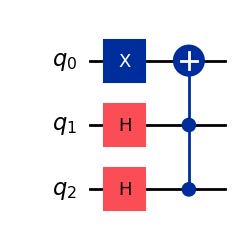

<IPython.core.display.Latex object>

In [3]:
q = QuantumRegister(3, name='q')
qc = QuantumCircuit(q)

## Iniciamos el estado
qc.x(q[0])
qc.h(q[1])
qc.h(q[2])
qc.ccx(q[2],q[1],q[0])

display(qc.draw('mpl'))

# Mostramos el vector de estado
estado = Statevector.from_circuit(qc)
estado.draw('latex')

## Codificación en amplitud

Un vector de $2^n$ elementos puede ser codificado en las amplitudes de $n$ cúbits.

Ventajas:

1. Permite almacenar hasta $2^n$ amplitudes en $n$ cúbits

Inconvenientes:

1. El número de elementos del vector debe ser potencia de 2: necesario aplicar *padding*
1. El vector debe estar normalizado
1. El proceso de codificación no es trivial
  - El número de puertas crece exponencialmente con el número de qubits $\mathcal{O}(2^n)$

Uso práctico: necesidad de [QRAM](https://en.wikipedia.org/wiki/Quantum_memory) que permita cargar datos clásicos en registros cuánticos (no existe todavía).

**Ejemplo**: inicialización de un vector de $2^n$ elementos en un sistema fake de IBMQ:

In [6]:
n = 5
# Creamos un vector aleatorio de 2**n elementos
v = np.random.random(2**n)
print(v)

[0.23370272 0.66944873 0.99567838 0.09046822 0.88455061 0.06377223
 0.37964257 0.2487929  0.62619661 0.21505938 0.12821855 0.98178711
 0.00727146 0.41044525 0.26417155 0.76802584 0.0261028  0.84788141
 0.28368016 0.03225604 0.51279167 0.79401547 0.83841082 0.89464234
 0.21817574 0.7032104  0.87809182 0.87665509 0.59927379 0.61824323
 0.87858417 0.68138808]


In [7]:
# Normalizamos v
vnorm = v / np.linalg.norm(v)
print(np.linalg.norm(vnorm))
print(vnorm)

0.9999999999999999
[0.06746751 0.19326279 0.28744185 0.02611722 0.25536043 0.01841037
 0.10959881 0.07182389 0.18077636 0.06208537 0.03701534 0.28343158
 0.00209919 0.11849121 0.07626354 0.22172096 0.0075356  0.24477442
 0.08189547 0.00931198 0.14803755 0.22922389 0.24204036 0.25827381
 0.06298503 0.20300942 0.25349584 0.25308108 0.17300402 0.1784803
 0.25363798 0.19670955]


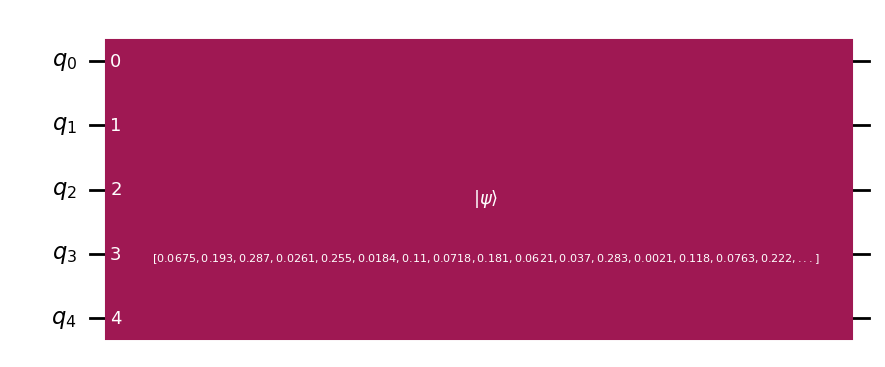

<IPython.core.display.Latex object>

In [8]:
# Iniciamos un circuito de n cúbits al vector normalizado
qc = QuantumCircuit(n)
qc.initialize(vnorm)
display(qc.draw('mpl'))
# Mostramos el vector de estado
estado = Statevector.from_circuit(qc)
estado.draw('latex')

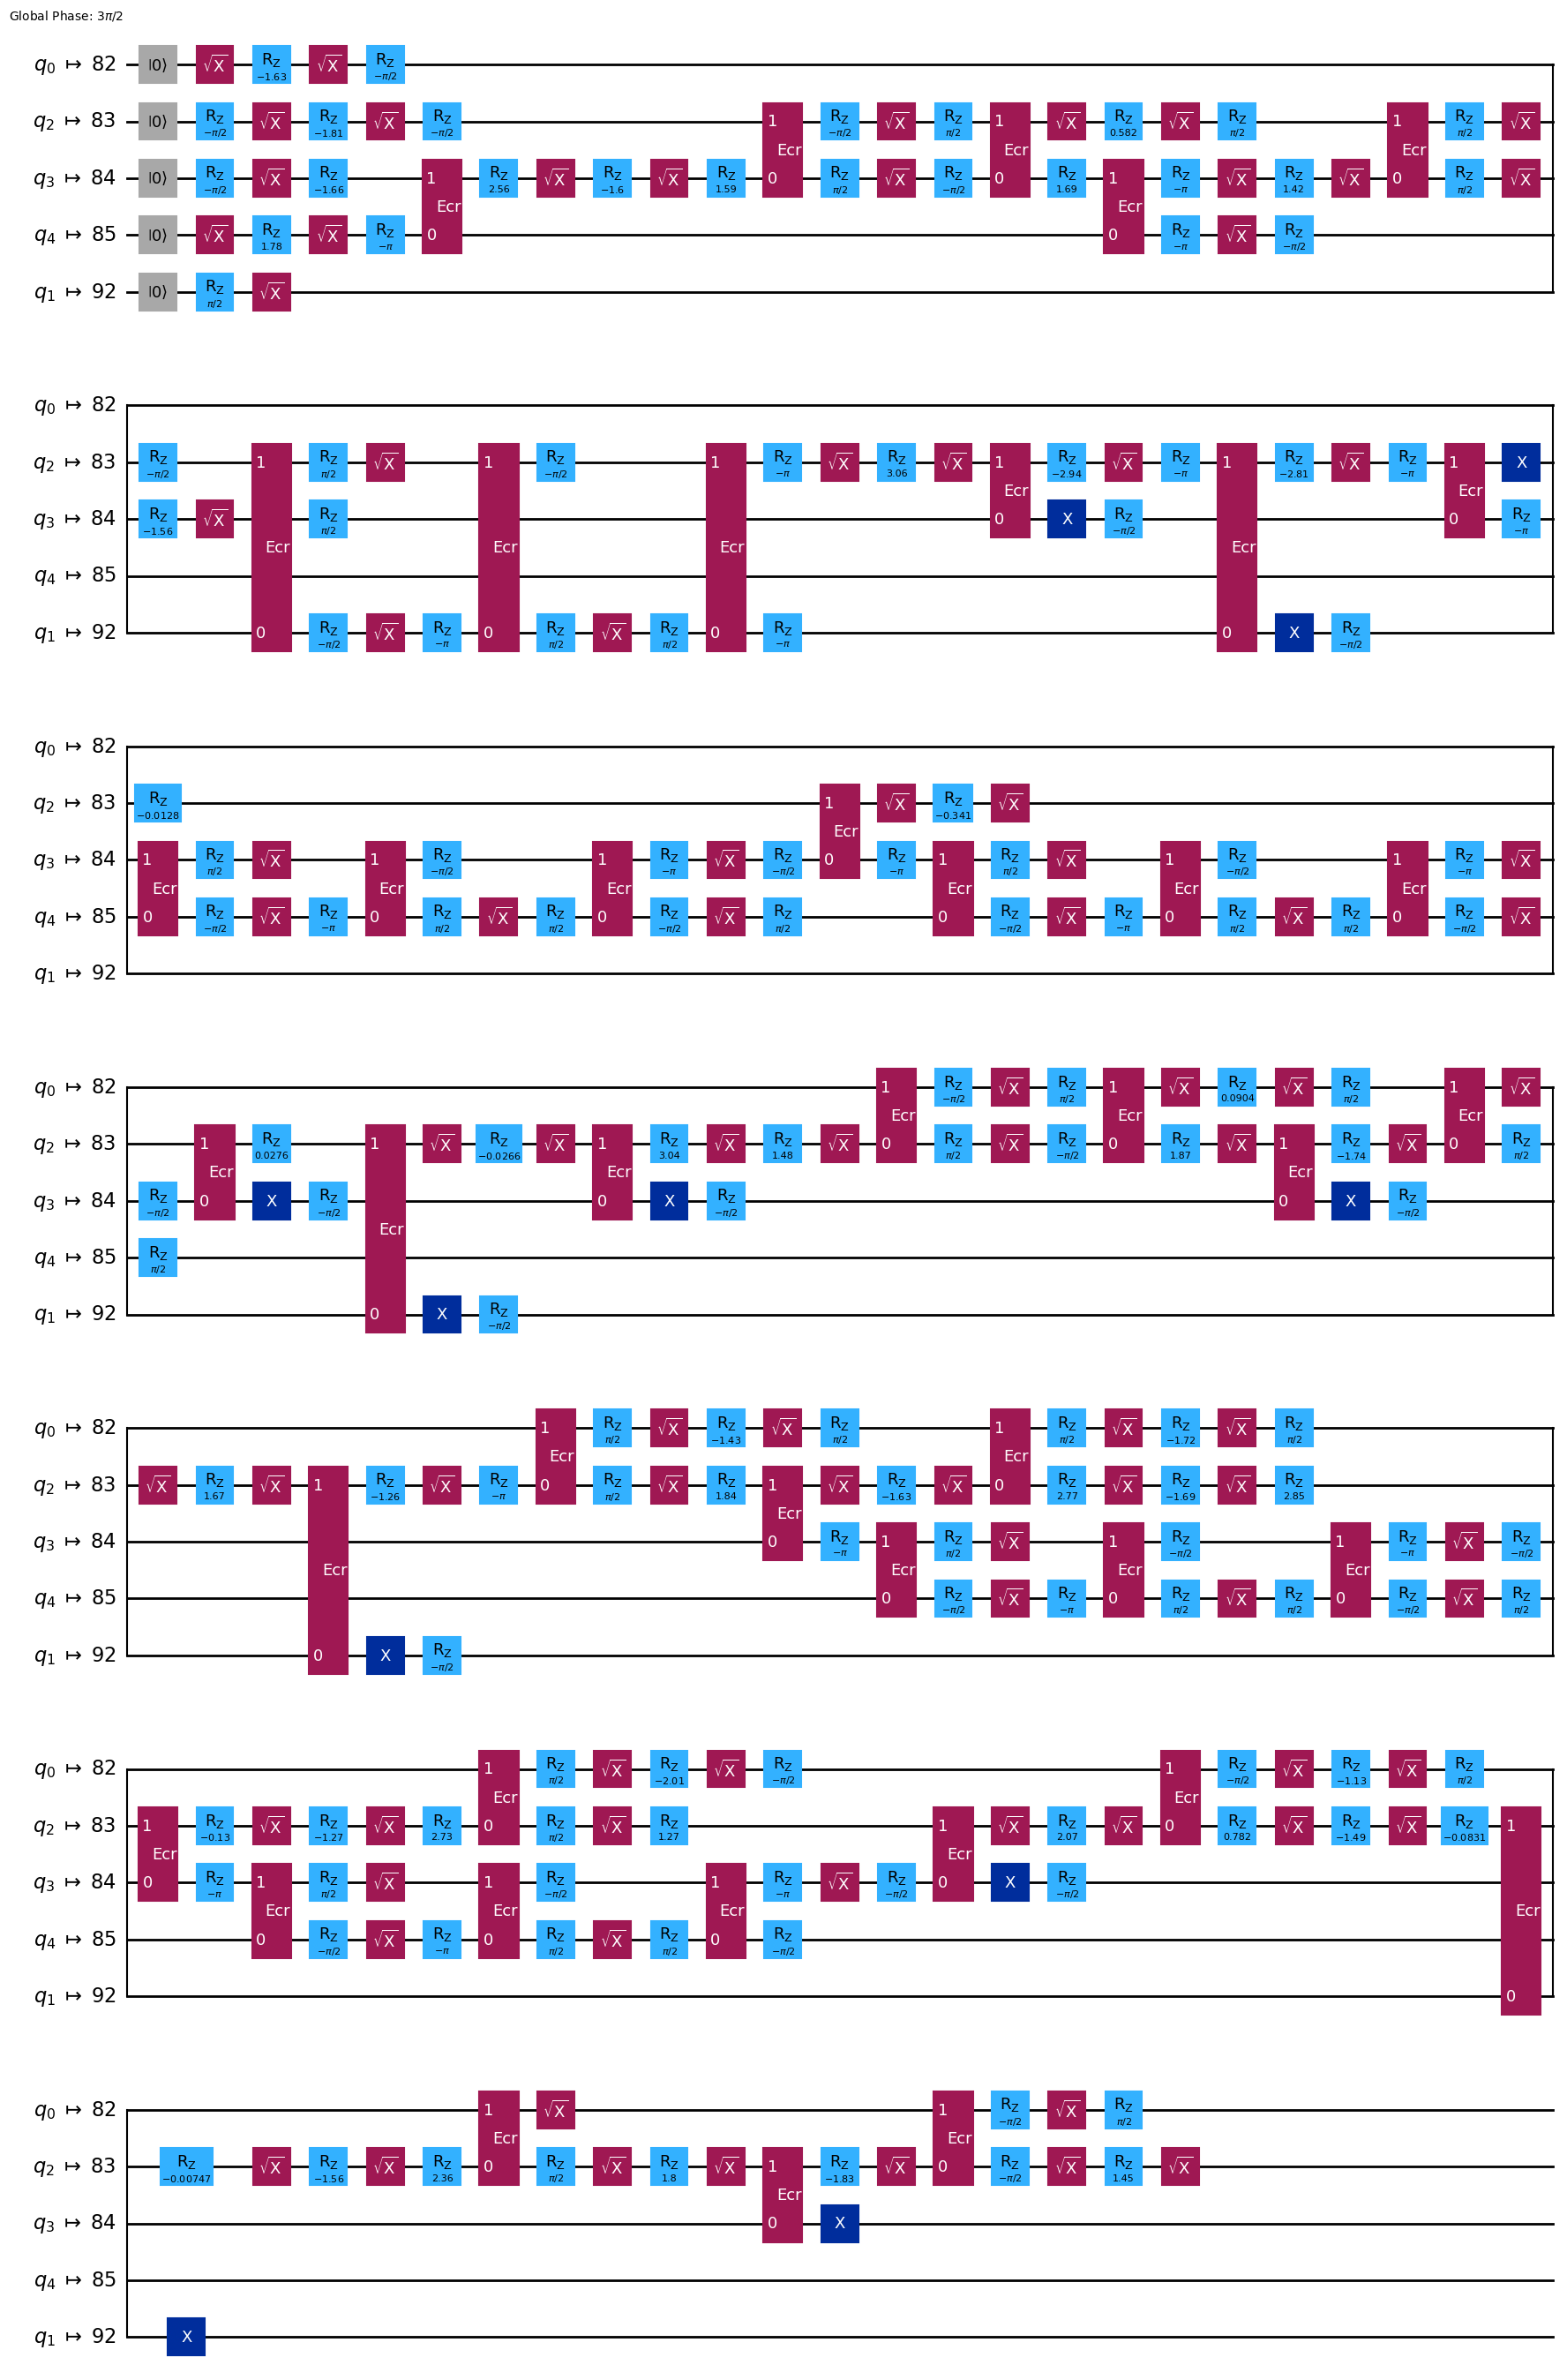

In [11]:
# Traspilamos a un FakeProvider
from qiskit_ibm_runtime.fake_provider import FakeOsaka

fake_backend = FakeOsaka()

# Creamos el Pass manager para ese backend
qc_transpilado = transpile(qc, fake_backend)


qc_transpilado.draw("mpl", idle_wires=False)

## Codificación en ángulos (Angle encoding)

Aplicamos a cada cúbit una rotación con un ángulo igual al valor a codificar

  - Necesitamos tantos cúbits como valores a codificar
  - Valores normalizados al intervalo $[-\pi,\pi]$
  - Fácil implementación: usualmente puertas $R_y$

  $$
R_y(x) =
\begin{bmatrix}
\cos\frac{x}{2}   & -\sin\frac{x}{2}\\
\sin\frac{x}{2} & \cos\frac{x}{2}
\end{bmatrix}
$$

$$
R_y(x)|0\rangle = \cos\frac{x}{2}|0\rangle + \sin\frac{x}{2}|1\rangle
$$

Vector a codificar [0.63168364 0.06351564 0.35780062 0.37214172]


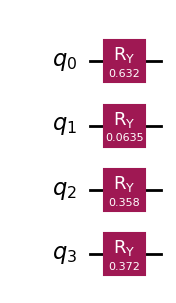

<IPython.core.display.Latex object>

In [12]:
n = 4 # Número de cúbits
v = np.random.random(n)
print(f'Vector a codificar {v}')

qc = QuantumCircuit(n)
for q in range(n):
    qc.ry(v[q], q)

display(qc.draw('mpl'))

# Mostramos el vector de estado
estado = Statevector.from_circuit(qc)
estado.draw('latex')

## Codificación en la fase (Phase encoding)

Similar al *angle encoding* pero usando puertas _phase shift_ que cambian la fase relativa:

$$
P_\theta  = \begin{bmatrix}1 & 0 \\ 0 & e^{i\theta} \end{bmatrix}
$$

Como $P_\theta|0\rangle = |0\rangle$ necesitamos usar una puerta $H$ antes de la $P_\theta$:

$$
P_x|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + e^{ix}|1\rangle
$$

## Dense angle encoding

Es una combinación de angle y phase encoding.

 - Usamos primero una $R_y$ y luego una $P$ con diferentes valores
 - Permite codificar $2n$ valores en $n$ cúbits


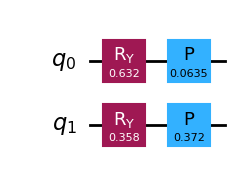

<IPython.core.display.Latex object>

In [13]:
qc = QuantumCircuit(n/2)
for q in range(0,n,2):
    qc.ry(v[q], q//2)
    qc.p(v[q+1],q//2)

display(qc.draw('mpl'))

# Mostramos el vector de estado
estado = Statevector.from_circuit(qc)
estado.draw('latex')

Codificaciones de orden más alto (_higher order encoding_) pueden implicar puertas Hadamard, CNOTs entre los cúbits y rotaciones con ángulo producto

  - Pueden ser útiles en determinados problemas

**Ejemplo**: [Efficient SU2](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.EfficientSU2)



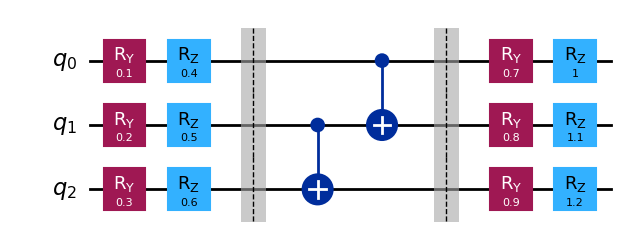

In [14]:
from qiskit.circuit.library import efficient_su2
# Codificamos un vector de 12 características en 3 cúbits
x = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
circuit = efficient_su2(num_qubits=3, reps=1, insert_barriers=True)
encode = circuit.assign_parameters(x)
encode.draw(output="mpl")



---



---



---



<a name="qsvm"></a>
# **Máquinas de soporte vectorial cuánticas (QSVMs)**

<center><img src="https://drive.google.com/uc?export=view&id=15Z8lqGOIpDCiAfUZRqMumMOXu-wAqcQM" alt="SVM clásico" width="800"  /></center>


## [Kernel trick](https://en.wikipedia.org/wiki/Kernel_trick)

Se usa una transformación no lineal (_feature map_) $\varphi(\mathbf{x})$ para mapear los datos desde el espacio
original a un nuevo espacio de más dimensiones (espacio de características) donde la superficie de decisión (hiperplano) se vuelva lineal.

El hiperplano en este espacio se puede escribir como:

$$\omega^T\varphi(\mathbf{x}) +b =0$$

y la función de clasificación:

$$y = \mathrm{label}(\mathbf{x}) = \mathrm{sign}(\omega^T\varphi(\mathbf{x}) +b)$$


### Forma dual

En vez de calcular el hiperplano, la denominada *forma dual* permite expresar en problema como una maximización de los _multiplicadores de Lagrange_ $\alpha_i$:

$$
\max_\alpha C_D(\alpha) = \sum_{i\in T} \alpha_i - \frac{1}{2}\sum_{i,j\in T} y_i y_j\alpha_i\alpha_j\langle\varphi(\mathbf{x_i})|\varphi(\mathbf{x_j})\rangle
$$
donde $T$ es el conjunto de entrenamiento y los valores $\alpha_i\ge 0$ solo son no-nulos para los vectores soporte en $T$.

La función de clasificación se puede escribir ahora como:

$$\mathrm{label}(\mathbf{s}) = \mathrm{sign}\left(\sum_{i\in V}\alpha_iy_iK(\mathbf{s},\mathbf{x_i}) +b\right)$$

donde $V$ es el conjunto de vectores soporte, $K$ la _función kernel_:

$$
K(\mathbf{x_i},\mathbf{x_j}) = K_{ij} = \langle\varphi(\mathbf{x_i})|\varphi(\mathbf{x_j})\rangle
$$

y $b$ se obtiene a partir de cualquier vector de soporte $x_k$:

$$
b = y_k - \sum_{i\in T} \alpha_i y_i K(\mathbf{x_i}, \mathbf{x_k})
$$


Los valores de la función (o matrix) kernel $K$ proporcionan una medida de _similaridad_ entre puntos en el espacio de características.

Esta matriz puede obtenerse sin necesidad de computar los productos internos $\langle\varphi(\mathbf{x_i})|\varphi(\mathbf{x_j})\rangle$ a través de funciones que codifiquen de forma implícita el feature map.

Ejemplo: [Radial Basis Function Kernel](https://en.wikipedia.org/wiki/Radial_basis_function_kernel)

$$
K(\mathbf{x_i},\mathbf{x_j}) = \exp\left(-\frac{\lVert \mathbf{x_i}-\mathbf{x_j}\rVert^2}{2\sigma²}\right)
$$

## SVMs cuánticas

Existen dos propuestas principales de SVMs cuánticas: los *clasificadores variacionales cuánticos* (VQC) y los *estimadores de kernel cuánticos* (QKE)



### Variational Quantum Classifier (VQC)

<center><img src="https://drive.google.com/uc?export=view&id=10kCs4HAuz-5oEisufPGajVtzPMysnTpB" alt="Variational Quantum Classifier (VQC)" width="500"  /></center>

Se trata de un clasificador lineal dentro de un espacio de características de alta dimensión.

Bloques:

  - El primer circuito define el *feature map*: $\varphi(\mathbf{x}) = \Phi(\mathbf{x})|0\rangle$
  - $W_\theta$ es un circuito variacional parametrizado por los valores $\theta$ y determina el hiperplano de separación.

La salida del circuito es el estado:

$$
|\Psi\rangle = W_\theta\Phi(x) |0\rangle
$$


Midiendo el valor esperado del observable Z obtenemos el clasificador:

$$
f_\theta(x) = \langle\Psi|Z|\Psi\rangle = \langle 0|\Phi^\dagger(x)W^\dagger_\theta ZW_\theta\Phi(x)|0\rangle \in [-1,1]
$$

Para la función de clasificación se elige un umbral $b\in [-1,1]$ y se define:

$$
\text{label}(x) =  \left\lbrace
\begin{array}{ll}
+1 & \text{si } f_\theta(x) \ge b\\
-1 & \text{si } f_\theta(x) < b
\end{array}
\right.
$$

Se puede demostrar que este modelo es un clasificador lineal en el espacio de características $\Phi(x)$ y $W_\theta$ parametriza el hiperplano.

Limitación: $W_\theta$ limitado por la profundidad del circuito $\Rightarrow$ no se puede probar con todos los hiperplanos posibles $\Rightarrow$ es posible que no se encuentre la solución óptima.



### Quantum Kernel Estimator (QKE)

Usa el computador cuántico solo para estimar la matriz kernel $K$.

<center><img src="https://drive.google.com/uc?export=view&id=1naiNKfs5wrUw65xwvJf4EOA4qUDM_r36" alt="Quantum Kernel Estimator (QKE)" width="450"  /></center>

De nuevo, se define el *feature map* como: $\varphi(\mathbf{x}) = \Phi(\mathbf{x})|0\rangle$



La salida del circuito para un par de vectores de características $\mathbf{x_i}$ y $\mathbf{x_j}$ es:

$$
|\Psi\rangle = \Phi(\mathbf{x_j})^\dagger\Phi(\mathbf{x_i})|0\rangle
$$

La regla de Born nos dice que la probabilidad de obtener el estado $|0\rangle$ a la salida es:

$$
\text{Pr}(|0\rangle) = |\langle0|\Psi\rangle|^2 = |\langle0|\Phi(\mathbf{x_j})^\dagger\Phi(\mathbf{x_i})|0\rangle|^2 = |\langle\varphi(\mathbf{x_j})|\varphi(\mathbf{x_i})\rangle|^2
$$

Obtenemos la matriz kernel cuántica (_quantum kernel_) midiendo la probabilidad de obtener el estado $|0\rangle$ a la salida del circuito:

$$
K_{i,j} = |\langle0|\Phi(\mathbf{x_j})^\dagger\Phi(\mathbf{x_i})|0\rangle|^2
$$

En este caso, los valores de $K$ proporcionan una medida de solapamiento (_overlap_) entre los estados $|\varphi(\mathbf{x_i})\rangle$ y $|\varphi(\mathbf{x_j})\rangle$.

Se ha demostrado que QKE solo proporciona ventaja frente a un sistema clásico si $\varphi(\mathbf{x})$ es suficientemente compleja y difícil de simular clásicamente.

### Ejemplos de *feature maps* en Qiskit

Qiskit tiene implementados algunos *feature maps* cuánticos:
  
  - [`ZFeatureMap`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.z_feature_map)
  - [`ZZFeatureMap`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.zz_feature_map)
  - [`PauliFeatureMap`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.pauli_feature_map)
  
En concreto, el ZZFeatureMap esta considerado como difícil de simular en un sistema clásico.

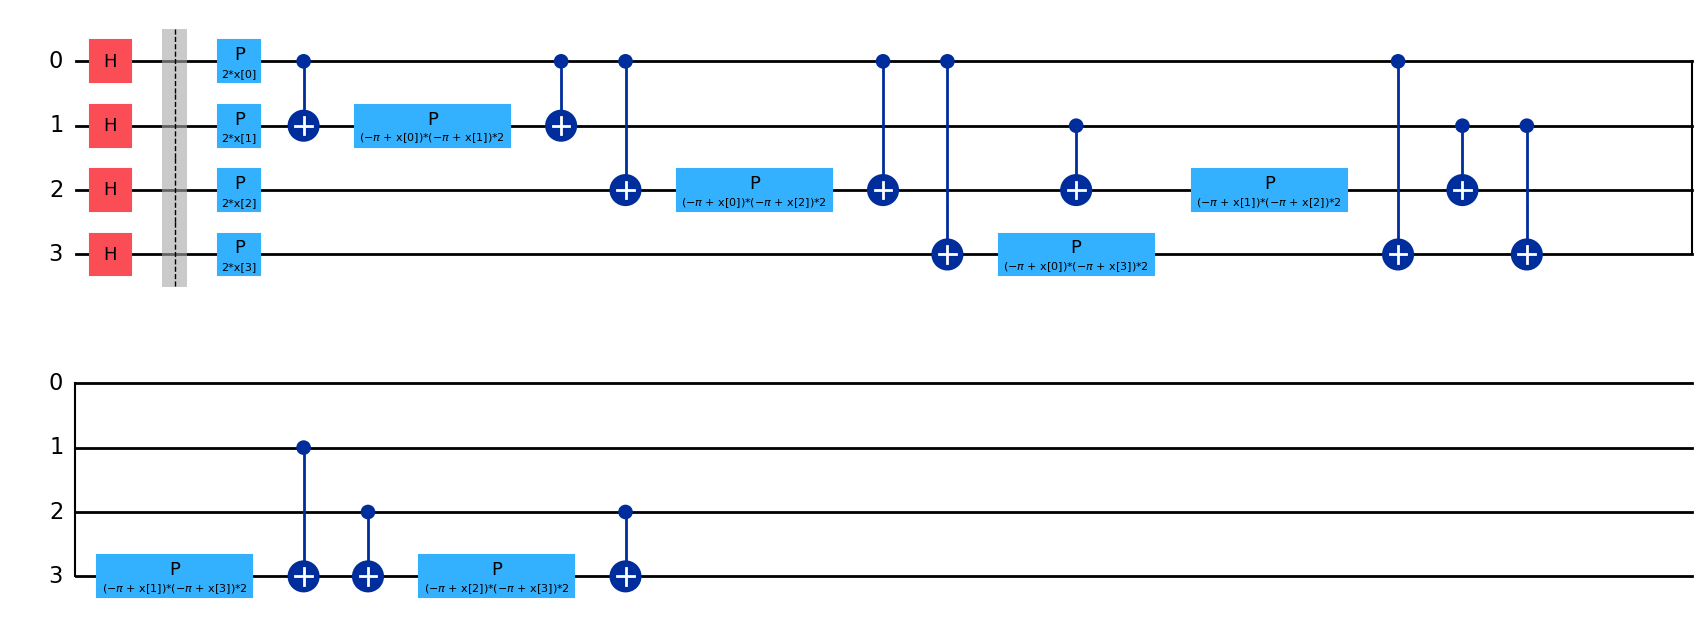

In [26]:
from qiskit.circuit.library import zz_feature_map

map_zz = zz_feature_map(feature_dimension=4, reps=1, entanglement='full', insert_barriers=True)
map_zz.draw('mpl')


## Ejemplo de clasificación binaria con QKE

Ejemplo del [Qiskit Machine Learning Tutorial](https://qiskit.org/documentation/machine-learning/tutorials/03_quantum_kernel.html).

Este ejemplo usa QKE con el usa el dataset descrito en https://arxiv.org/pdf/1804.11326.pdf y obtiene la matriz kernel cuántica. Ver [aquí](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.datasets.ad_hoc_data.html) para detalles sobre los datos.

Para crear la matriz kernel cuántica usa la clase [FidelityQuantumKernel](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.kernels.FidelityQuantumKernel.html).

Como feature_map usa [ZZFeatureMap](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.ZZFeatureMap).

En la parte clásica, usa el algoritmo [SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC) (_Support Vector Machine Classification_) del módulo de [SVM](https://scikit-learn.org/stable/modules/svm.html) de la librería [scikit-learn](https://scikit-learn.org/stable/).

In [60]:
from qiskit_machine_learning.datasets import ad_hoc_data
from qiskit_machine_learning.utils import algorithm_globals

algorithm_globals.random_seed = 12345

adhoc_dimension = 2
# adhoc_total son todos los puntos en una rejilla uniforme de la que se seleccionan las muestras
train_features, train_labels, test_features, test_labels, adhoc_total = ad_hoc_data(
    training_size=20, # 20 datos de cada clase, 40 en total
    test_size=5,      # 5 datos de cada clase, 10 en total
    n=adhoc_dimension,
    gap=0.3,  # Distancia mínima de separación entre las regiones de las dos clases
    plot_data=False,
    one_hot=False,   # Si True, devuelve las etiquitas en formato one-hot.
    include_sample_total=True,
)

In [61]:
print(adhoc_total[0])

50


El dataset es bidimensional. Las dos características corresponden a coordenadas $x$ e $y$, y tiene dos clases, con etiquetas A y B. Las siguientes funciones permiten visualizarlo.

In [62]:
import matplotlib.pyplot as plt
import numpy as np

def plot_features(ax, features, labels, class_label, marker, face, edge, label):
    # A train plot
    ax.scatter(
        # x coordinate of labels where class is class_label
        features[np.where(labels[:] == class_label), 0],
        # y coordinate of labels where class is class_label
        features[np.where(labels[:] == class_label), 1],
        marker=marker,
        facecolors=face,
        edgecolors=edge,
        label=label,
    )

def plot_dataset(train_features, train_labels, test_features, test_labels, adhoc_total):
    plt.figure(figsize=(5, 5))
    plt.ylim(0, 2 * np.pi)
    plt.xlim(0, 2 * np.pi)
    # Imprime la rejilla
    plt.imshow(
        np.asmatrix(adhoc_total).T,
        interpolation="nearest",
        origin="lower",
        cmap="RdBu",
        extent=[0, 2 * np.pi, 0, 2 * np.pi],
    )
    # Entrenamiento etiqueta A
    plot_features(plt, train_features, train_labels, 0, "s", "w", "b", "A entrenamiento")
    # Entrenamiento etiqueta B
    plot_features(plt, train_features, train_labels, 1, "o", "w", "r", "B entrenamiento")
    # Test etiqueta A
    plot_features(plt, test_features, test_labels, 0, "s", "b", "w", "A test")
    # Test etiqueta B
    plot_features(plt, test_features, test_labels, 1, "o", "r", "w", "B test")

    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)
    plt.title("Dataset ad hoc para clasificación")

    plt.show()

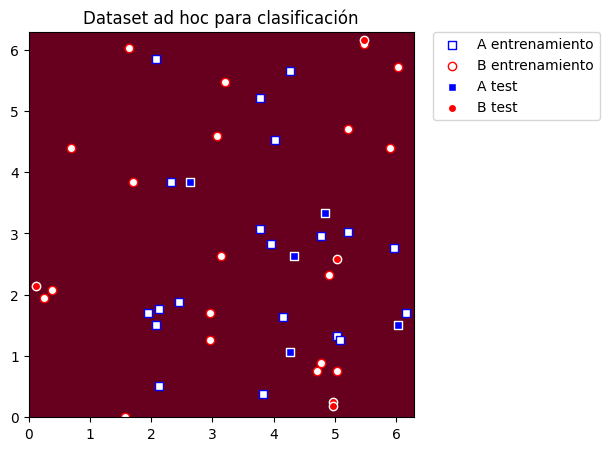

In [63]:
plot_dataset(train_features, train_labels, test_features, test_labels, adhoc_total)

#### Clasificación clásica



In [64]:
from sklearn.svm import SVC
model = SVC(kernel='rbf')
model.fit(train_features, train_labels)
print(f"Score: {model.score(test_features, test_labels)}")

Score: 0.7


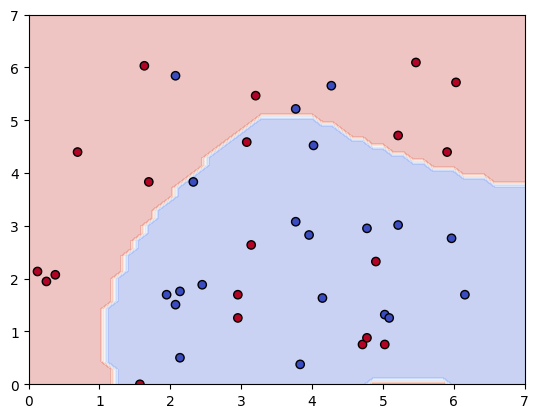

In [67]:
# Código rápido para visualizar la frontera que han creado
xx, yy = np.meshgrid(np.linspace(0, 7, 50), np.linspace(0, 7, 50))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(train_features[:, 0], train_features[:, 1], c=train_labels, cmap='coolwarm', edgecolors='k')
plt.show()

Creamos un QuantumKernel para la clasificación. Usaremos un [FidelityQuantumKernel](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.kernels.FidelityQuantumKernel.html) y como feature_map un [ZZFeatureMap](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.zz_feature_map).


In [56]:
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel

# Definimos el ZZFeatureMap con 2 repeticiones
adhoc_feature_map = zz_feature_map(feature_dimension=adhoc_dimension, reps=2, entanglement="linear")

adhoc_kernel = FidelityQuantumKernel(feature_map=adhoc_feature_map)

#### Clasificación usando SVC

El algortimo SVC de scikit-learn acepta dos formas de definir un kernel a medida.

La primera es pasándole la función que se encarga de computar la matriz kernel, que es el método evaluate del FidelityQuantumKernel

In [46]:
from sklearn.svm import SVC

# Le pasamos la función que se encarga de computar la matriz kernel
adhoc_svc = SVC(kernel=adhoc_kernel.evaluate)

# Le pasamos los datos de entrenamiento
adhoc_svc.fit(train_features, train_labels)

# Obtenemos la calificación media de la clasificación de los datos de test
adhoc_score_funcion = adhoc_svc.score(test_features, test_labels)

print(f'Calificación media con los datos de test: {adhoc_score_funcion}')


Calificación media con los datos de test: 0.7


La segunda forma es pasándole la matriz kernel precalculada.

Precalculamos las matrices $K(x_i,x_j)$ y $K(t_i, x_j)$ donde las $x$ son los datos de entrenamiento y las $t$ los de test

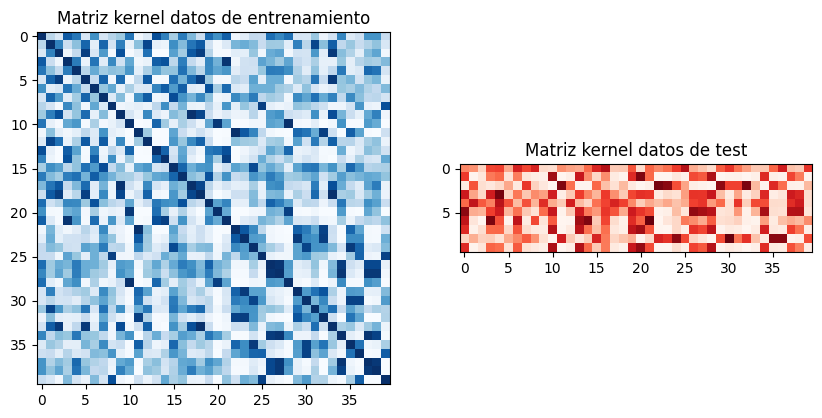

In [47]:
# Obtenemos la matriz kernel para los datos de entrenamiento
adhoc_matrix_train = adhoc_kernel.evaluate(x_vec=train_features)

# Obtenemos la matriz kernel para los datos de test
adhoc_matrix_test = adhoc_kernel.evaluate(x_vec=test_features,
                                          y_vec=train_features)
# Mostramos las matrices
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(np.asmatrix(adhoc_matrix_train),
              interpolation='nearest', origin='upper', cmap='Blues')
axs[0].set_title("Matriz kernel datos de entrenamiento")
axs[1].imshow(np.asmatrix(adhoc_matrix_test),
              interpolation='nearest', origin='upper', cmap='Reds')
axs[1].set_title("Matriz kernel datos de test")
plt.show()

In [48]:
# Ejecuta el SVC con las matrices precalculadas
adhoc_svc = SVC(kernel='precomputed')

# Le pasamos la matriz kelnel de entrenamiento y las etiquetas
adhoc_svc.fit(adhoc_matrix_train, train_labels)

# Obtenemos la calificación media de la clasificación de los datos de test
adhoc_score_precomputado = adhoc_svc.score(adhoc_matrix_test, test_labels)

print(f'Calificación media de los datos de test: {adhoc_score_precomputado}')

Calificación media de los datos de test: 0.7


#### Clasificación usando QSVC

[QSVC](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.QSVC.html#qsvc) es una función de conveniencia proporcionada por Qiskit.


In [44]:
from qiskit_machine_learning.algorithms import QSVC

qsvc = QSVC(quantum_kernel=adhoc_kernel)

qsvc.fit(train_features, train_labels)

qsvc_score = qsvc.score(test_features, test_labels)

print(f"QSVC: Calificación media de los datos de test: {qsvc_score}")

QSVC: Calificación media de los datos de test: 1.0




---



---



---



<a name="e9"></a>
# **✍️ Ejercicio entregable 9: dataset de círculos concéntricos**

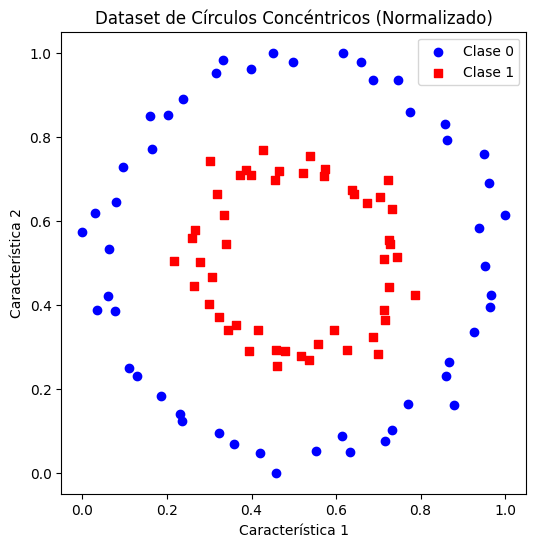

In [49]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# 1. Generar el dataset de círculos
# factor: relación de radio entre el círculo interno y externo (0.5 es buena separación)
# noise: añade dispersión para que no sea un círculo perfecto y sea más realista
features, labels = make_circles(n_samples=100, factor=0.5, noise=0.05, random_state=42)

# 2. Normalización (Escalado de características)
# Los feature maps cuánticos suelen esperar valores en el rango [0, 1] o [-1, 1]
# ya que estos valores se mapean directamente a ángulos de rotación (fases).
features = MinMaxScaler(feature_range=(0, 1)).fit_transform(features)

# 3. División en entrenamiento y test (similar a tu ejemplo previo)
train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, train_size=20, test_size=10, random_state=42
)

# 4. Visualización para tus alumnos
plt.figure(figsize=(6, 6))
for label, color, marker in zip([0, 1], ["blue", "red"], ["o", "s"]):
    mask = labels == label
    plt.scatter(features[mask, 0], features[mask, 1], c=color, label=f"Clase {label}", marker=marker)

plt.title("Dataset de Círculos Concéntricos (Normalizado)")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.legend()
plt.show()

In [54]:
from sklearn.svm import SVC
model = SVC(kernel='rbf') # O kernel='poly'
model.fit(train_features, train_labels)
print(f"Score: {model.score(test_features, test_labels)}")

Score: 1.0


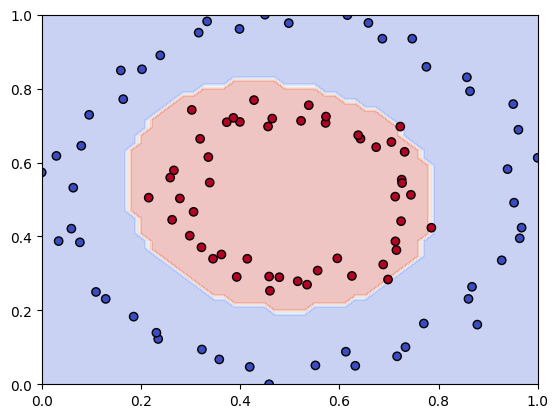

In [55]:
# Código rápido para visualizar la frontera que han creado
xx, yy = np.meshgrid(np.linspace(0, 1, 50), np.linspace(0, 1, 50))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(features[:, 0], features[:, 1], c=labels, cmap='coolwarm', edgecolors='k')
plt.show()

In [57]:
# Le pasamos la función que se encarga de computar la matriz kernel
qmodel = SVC(kernel=adhoc_kernel.evaluate)

# Le pasamos los datos de entrenamiento
qmodel.fit(train_features, train_labels)

# Obtenemos la calificación media de la clasificación de los datos de test
print(f"Score: {qmodel.score(test_features, test_labels)}")

Score: 0.7


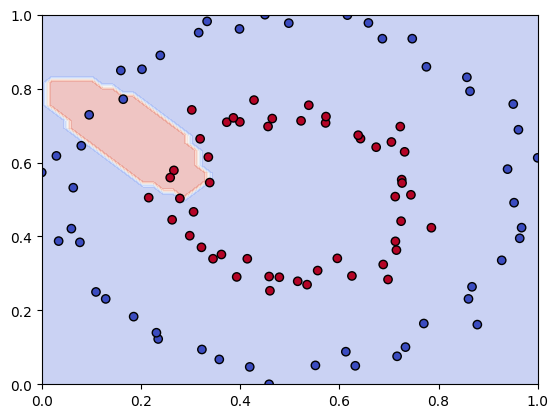

In [58]:
# Código rápido para visualizar la frontera que han creado
xx, yy = np.meshgrid(np.linspace(0, 1, 20), np.linspace(0, 1, 20))
Z = qmodel.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(features[:, 0], features[:, 1], c=labels, cmap='coolwarm', edgecolors='k')
plt.show()

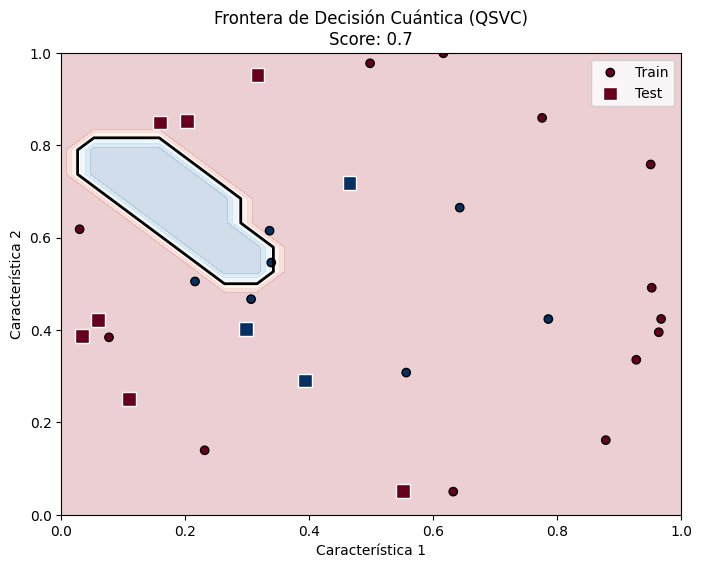

In [53]:
import numpy as np

# 1. Crear una malla de puntos que cubra el rango [0, 1] de tus datos normalizados
steps = 20  # Aumenta a 40 o 50 para más resolución (pero tardará más en computar el kernel)
x_min, x_max = 0, 1
y_min, y_max = 0, 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, steps),
                     np.linspace(y_min, y_max, steps))

# 2. Aplanar la malla para pasarla al modelo
grid_samples = np.c_[xx.ravel(), yy.ravel()]

# 3. Predecir la clase para cada punto de la malla
# Nota: Esto ejecutará muchos circuitos cuánticos, ten paciencia.
grid_predictions = qsvc.predict(grid_samples)
grid_predictions = grid_predictions.reshape(xx.shape)

# 4. Dibujar la frontera y los datos reales
plt.figure(figsize=(8, 6))

# Dibujar las áreas de decisión
plt.contourf(xx, yy, grid_predictions, alpha=0.2, cmap='RdBu')

# Dibujar la línea de la frontera (donde cambia de 0 a 1)
plt.contour(xx, yy, grid_predictions, levels=[0.5], colors='black', linewidths=2)

# Dibujar los puntos originales de entrenamiento
plt.scatter(train_features[:, 0], train_features[:, 1], c=train_labels,
            cmap='RdBu', edgecolors='k', marker='o', label='Train')
plt.scatter(test_features[:, 0], test_features[:, 1], c=test_labels,
            cmap='RdBu', edgecolors='white', marker='s', s=100, label='Test')

plt.title(f"Frontera de Decisión Cuántica (QSVC)\nScore: {qsvc_score}")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.legend()
plt.show()



---



---



---



<a name="qnn"></a>
# **Redes neuronales cuánticas (QNNs)**

<center><img src="https://drive.google.com/uc?export=view&id=1OHw-beJcEnrWXca_w7Cn6DydqweHJeCo" alt="QNN" width="900"  /></center>
(Fuente: Mangini, S. et al. (2021). Quantum computing models for artificial neural networks. EPL (Europhysics Letters), 134(1), 10002. <a href='https://doi.org/10.1209/0295-5075/134/10002'>https://doi.org/10.1209/0295-5075/134/10002</a>)

- Estructura similar, pero diferente flujo de información

Se han propuesto otros modelos de, por ejemplo, redes neuronales convolucionales cuánticas o redes neuronales tensoriales:

  - Li, Y., Zhou, R. G., Xu, R., Luo, J., & Hu, W. (2020). A quantum deep convolutional neural network for image recognition. Quantum Science and Technology, 5(4), 044003. http://www.doi.org/10.1088/2058-9565/ab9f93
  - Henderson, M., Shakya, S., Pradhan, S., & Cook, T. (2020). Quanvolutional neural networks: powering image recognition with quantum circuits. Quantum Machine Intelligence, 2(1), 1-9. http://www.doi.org/10.1007/s42484-020-00012-y
  - Grant, E., Benedetti, M., et al. (2018). Hierarchical quantum classifiers. npj Quantum Information, 4(1), 1-8 .https://doi.org/10.1038/s41534-018-0116-9
  

## Librerías de QML

Muchos algoritmos están implementados en librerías de alto nivel:

#### [Qiskit ML](https://qiskit-community.github.io/qiskit-machine-learning/)

- Algoritmos antes incluidos en [Qiskit Aqua](https://github.com/Qiskit/qiskit-aqua)
    - Qiskit Aqua separado en [_Optimization_](https://qiskit-community.github.io/qiskit-optimization/), [_Finance_](https://qiskit-community.github.io/qiskit-finance/), [_Machine Learning_](https://qiskit-community.github.io/qiskit-machine-learning/) y [_Nature_](https://qiskit-community.github.io/qiskit-nature/)
- Ejemplos:
    - [Quantum Kernel Machine Learning](https://qiskit.org/documentation/machine-learning/tutorials/03_quantum_kernel.html)
    - [Quantum Neural Networks](https://qiskit.org/documentation/machine-learning/tutorials/01_neural_networks.html)
    - [Neural Network Classifier & Regressor](https://qiskit.org/documentation/machine-learning/tutorials/02_neural_network_classifier_and_regressor.html)
    - [PyTorch qGAN (Quantum Generative Adversarial Network) Implementation](https://qiskit.org/ecosystem/machine-learning/tutorials/04_torch_qgan.html)
- Permite diseñar redes neuronales híbridas con PyTorch

<center><img src="https://drive.google.com/uc?export=view&id=1Pi-UZ5KMHsxIjU-Mj2bn26NkfIrFTsEh" alt="Red neuronal híbrida" width="800"  /></center>
    
#### [Pennylane](https://pennylane.ai/)

- Librería cross-platform para [programación diferenciable](https://en.wikipedia.org/wiki/Differentiable_programming) de computadores cuánticos
- Desarrollada por la empresa [Xanadu Quantum Technologies](https://www.xanadu.ai/)
- Integra librerías de ML con diferentes simuladores y hardware cuántico:
    - [IBM Qiskit](https://docs.pennylane.ai/projects/qiskit/), [Microsoft Q#](https://docs.pennylane.ai/projects/qsharp), [Cirq](https://docs.pennylane.ai/projects/cirq), [Amazon Braket](https://amazon-braket-pennylane-plugin-python.readthedocs.io/en/latest/), etc.
    - Más info: https://pennylane.ai/plugins.html
- Interfaces con [Numpy](https://pennylane.readthedocs.io/en/stable/introduction/interfaces/numpy.html), [TensorFlow](https://pennylane.readthedocs.io/en/stable/introduction/interfaces/tf.html), [PyTorch](https://pennylane.readthedocs.io/en/stable/introduction/interfaces/torch.html) y [JAX](https://pennylane.readthedocs.io/en/stable/introduction/interfaces/jax.html)
- Más información:
    - Documentación: https://pennylane.readthedocs.io/
    - Demos: https://pennylane.ai/qml/demonstrations.html
    
#### [TensorFlow Quantum](https://www.tensorflow.org/quantum)

- Framework Python para Quantum Machine Learning
- Modelos híbridos clásicos-cuánticos
- Diseñado para trabajar con [Google Circ](https://quantumai.google/cirq)

<center><img src="https://drive.google.com/uc?export=view&id=1qdmRxTe5PgzpqLaksqwv9EaaHdNcXwx8" alt="TensorFlow" width="800"  /></center>
(Fuente: <a href='https://ai.googleblog.com/2020/03/announcing-tensorflow-quantum-open.html'>https://ai.googleblog.com/2020/03/announcing-tensorflow-quantum-open.html</a>)

#### Referencias:

  - Peral-García, D., Cruz-Benito, J., & García-Peñalvo, F. J. (2024). Systematic literature review: Quantum machine learning and its applications. Computer Science Review, 51, 100619. https://doi.org/10.1016/j.cosrev.2024.100619
  - Jerbi, S., Fiderer, L. J., Poulsen Nautrup, H., Kübler, J. M., Briegel, H. J., & Dunjko, V. (2023). Quantum machine learning beyond kernel methods. Nature Communications, 14(1), 1-8. https://www.nature.com/articles/s41467-023-36159-y
  - Cerezo, M., Verdon, G., Huang, H. Y., Cincio, L., & Coles, P. J. (2022). Challenges and opportunities in quantum machine learning. Nature Computational Science, 2(9), 567-576. https://www.nature.com/articles/s43588-022-00311-3
  - Huang, H. Y., Broughton, M., Mohseni, M., Babbush, R., Boixo, S., Neven, H., & McClean, J. R. (2021). Power of data in quantum machine learning. Nature communications, 12(1), 2631. https://www.nature.com/articles/s41467-021-22539-9
  - Liu, Y., Arunachalam, S., & Temme, K. (2021). A rigorous and robust quantum speed-up in supervised machine learning. Nature Physics, 1-5. https://doi.org/10.1038/s41567-021-01287-z  
  - Beer, K., Bondarenko, D., Farrelly, T., Osborne, T. J., Salzmann, R., Scheiermann, D., & Wolf, R. (2020). Training deep quantum neural networks. Nature communications, 11(1), 1-6, https://www.nature.com/articles/s41467-020-14454-2
  - Havlíček, V., Córcoles, A. D., Temme, K., Harrow, A. W., Kandala, A., Chow, J. M., & Gambetta, J. M. (2019). Supervised learning with quantum-enhanced feature spaces. Nature, 567(7747), 209-212. https://doi.org/10.1038/s41586-019-0980-2 https://arxiv.org/pdf/1804.11326.pdf
  - Schuld, M., Sweke, R., & Meyer, J. J. (2021). Effect of data encoding on the expressive power of variational quantum-machine-learning models. Physical Review A, 103(3), 032430. https://doi.org/10.1103/PhysRevA.103.032430
    
Más referencias en https://quantumalgorithmzoo.org/



---



---



---



<a name="otras"></a>
# **Otras aplicaciones**

El uso de la computación cuántica se ha extendido a muchos otros campos

![Campos de uso](https://github.com/tarabelo/2024-VIU-Quantum/blob/main/images/ecosistema2.png?raw=1)
(Fuente: https://www.bcg.com/publications/2018/next-decade-quantum-computing-how-play, 2018)

### Finanzas

En el ámbito financiero es en el que se ha despertado un mayor interés por la computación cuántica como mecanismo de acelerar sus operaciones.

- Herman, D., Googin, C., Liu, X., Sun, Y., Galda, A., Safro, I., ... & Alexeev, Y. (2023). Quantum computing for finance. Nature Reviews Physics, 5(8), 450-465. https://www.nature.com/articles/s42254-023-00603-1
- Wilkens, S., & Moorhouse, J. (2023). Quantum computing for financial risk measurement. Quantum Information Processing, 22(1), 51. https://doi.org/10.1007/s11128-022-03777-2
- Naik, A., Yeniaras, E., Hellstern, G., Prasad, G., & Vishwakarma, S. K. L. P. (2023). From portfolio optimization to quantum blockchain and security: A systematic review of quantum computing in finance. arXiv preprint arXiv:2307.01155. https://arxiv.org/abs/2307.01155
- Egger, D. J., Gambella, C., Marecek, J., McFaddin, S., Mevissen, M., Raymond, R., ... & Yndurain, E. (2020). Quantum computing for finance: State-of-the-art and future prospects. IEEE Transactions on Quantum Engineering, 1, 1-24. https://doi.org/10.1109/TQE.2020.3030314
- Egger, D. J., Gutierrez, R. G., Mestre, J. C., & Woerner, S. (2020). Credit risk analysis using quantum computers. IEEE Transactions on Computers. https://doi.org/10.1109/TC.2020.3038063
- McKinsey & Company (2020) [_How quantum computing could change financial services](https://www.mckinsey.com/industries/financial-services/our-insights/how-quantum-computing-could-change-financial-services)
- IBM, [_Exploring quantum computing use cases for financial services_](https://www.ibm.com/thought-leadership/institute-business-value/report/exploring-quantum-financial)
- [Qiskit Finance Tutorials](https://qiskit.org/documentation/tutorials/finance/index.html)

### Procesamiento de imágenes y visión por computador

Existen diferentes mecanismos de representación de imágenes que permiten una codificación eficiente de una imagen clásica en un estado cuántico, por ejemlo _Flexible Representation of Quantum Images (FRQI)_ ([Le, P.Q., Dong, F. & Hirota, K, 2011](https://doi.org/10.1007/s11128-010-0177-y)) y _Novel Enhanced Quantum Representation (NEQR) for Digital Images_ ([Zhang, Y., Lu, K., Gao, Y. et al., 2013](https://doi.org/10.1007/s11128-013-0567-z))

**Otros trabajos**

- Yan, F., Venegas-Andraca, S. E., & Hirota, K. (2022). Toward implementing efficient image processing algorithms on quantum computers. Soft Computing, 1-13. https://doi.org/10.1007/s00500-021-06669-2
- Wang, Z., Xu, M., & Zhang, Y. (2022). Review of quantum image processing. Archives of Computational Methods in Engineering, 29(2), 737-761. https://doi.org/10.1007/s11831-021-09599-2
- Das, S., Zhang, J., Martina, S., Suter, D., & Caruso, F. (2023). Quantum pattern recognition on real quantum processing units. Quantum Machine Intelligence, 5(1), 16. https://doi.org/10.1007/s42484-022-00093-x
- Zhou, N. R., Liu, X. X., Chen, Y. L., & Du, N. S. (2021). Quantum K-Nearest-Neighbor Image Classification Algorithm Based on KL Transform. International Journal of Theoretical Physics, 1-16. https://doi.org/10.1007/s10773-021-04747-7

### Bioinformática y genética

- Chagneau, A., Massaoudi, Y., Derbali, I., & Yahiaoui, L. (2024). Quantum algorithm for bioinformatics to compute the similarity between proteins. IET Quantum Communication. https://ietresearch.onlinelibrary.wiley.com/doi/full/10.1049/qtc2.12098
- Mokhtari, M., Khoshbakht, S., Ziyaei, K., Akbari, M. E., & Moravveji, S. S. (2024). New classifications for quantum bioinformatics: Q-bioinformatics, QCt-bioinformatics, QCg-bioinformatics, and QCr-bioinformatics. Briefings in Bioinformatics, 25(2), bbae074. https://academic.oup.com/bib/article/25/2/bbae074/7621030
- Fedorov, A. K., & Gelfand, M. S. (2021). Towards practical applications in quantum computational biology. Nature Computational Science, 1(2), 114-119. https://www.nature.com/articles/s43588-021-00024-z
- Sarkar, A., Al-Ars, Z., Almudever, C. G., & Bertels, K. (2019). An algorithm for DNA read alignment on quantum accelerators. arXiv preprint [arXiv:1909.05563](https://arxiv.org/abs/1909.05563)
- Sarkar, A., Al-Ars, Z., & Bertels, K. (2021). QuASeR: Quantum Accelerated de novo DNA sequence reconstruction. Plos one, 16(4), e0249850 https://doi.org/10.1371/journal.pone.0249850
- Cordier, B. A., Sawaya, N. P., Guerreschi, G. G., & McWeeney, S. K. (2022). Biology and medicine in the landscape of quantum advantages. Journal of the Royal Society Interface, 19(196). https://doi.org/10.1098/rsif.2022.0541

### Robótica

- Atchade-Adelomou P., Alonso-Linaje, G., Albo-Canals, J., Casado-Fauli, D. (2021). qRobot: A Quantum computing approach in mobile robot order picking and batching problem solver optimization. arXiv preprint [arXiv:2105.04865](https://arxiv.org/abs/2105.04865)
- Mannone, M., Seidita, V., & Chella, A. (2023). Modeling and designing a robotic swarm: A quantum computing approach. Swarm and Evolutionary Computation, 79, 101297. https://doi.org/10.1016/j.swevo.2023.101297
- Chella, A., Gaglio, S., Mannone, M., Pilato, G., Seidita, V., Vella, F., & Zammuto, S. (2023). Quantum planning for swarm robotics. Robotics and Autonomous Systems, 161, 104362. https://doi.org/10.1016/j.robot.2023.104362


## Algunas empresas de tecnologías cuánticas

<center><img src="https://drive.google.com/uc?export=view&id=1YWunTU_o6aM6cBjII2WnOAgo12j_fZTi" alt="Ecosistema empresarial" width="800"  /></center>

(Fuente: https://www.bcg.com/publications/2018/next-decade-quantum-computing-how-play, 2018)

